# Homework 1: Thinking About Data

BEE 4850/5850

**Name**: Liying Ma

**ID**: Lm698

> **Due Date**
>
> Friday, 2/7/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to introduce you to
simulation-based data analysis.

-   Problem 1 asks you to find an example of a spurious correlation.
-   Problem 2 asks you to explore whether a difference between data
    collected from two groups might be statistically meaningful or the
    result of noise. This problem repeats the analysis from [Statistics
    Without The Agonizing
    Pain](https://www.youtube.com/watch?v=5Dnw46eC-0o) by John Rauser
    (which is a neat watch!).
-   Problem 3 asks you to explore the impacts of selection biases on
    statistical relationships.
-   Problem 4 asks you to evaluate an interview method for finding the
    level of cheating on a test to determine whether cheating was
    relatively high or low. This problem was adapted from [Bayesian
    Methods for
    Hackers](https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/).
-   Problem 5 (only required for students in BEE 5850) asks you to
    propose several causal models for the same observational phenomenon.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4850/HW/hw01-LM698`
   Installed OffsetArrays ──────────── v1.15.0
   Installed Xorg_xkbcomp_jll ──────── v1.4.6+1
   Installed FFTW ──────────────────── v1.8.0
   Installed HypergeometricFunctions ─ v0.3.25
   Installed JpegTurbo_jll ─────────── v3.1.0+1
   Installed Libmount_jll ──────────── v2.40.2+1
   Installed ConcurrentUtilities ───── v2.4.3
   Installed DoubleFloats ──────────── v1.4.2
   Installed HTTP ──────────────────── v1.10.15
   Installed GR_jll ────────────────── v0.73.10+0
   Installed FileIO ────────────────── v1.16.6
   Installed LERC_jll ──────────────── v4.0.0+2
   Installed InvertedIndices ───────── v1.3.1
   Installed NearestNeighbors ──────── v0.4.21
   Installed Fontconfig_jll ────────── v2.15.0+0
   Installed Xorg_libxkbfile_jll ───── v1.1.2+1
   Installed IntelOpenMP_jll ───────── v2024.2.1+0
   Installed Xorg_libXinerama_jll ──── v1.1.5+0
   Installed Libgpg_error_jll ──────── v1.51.0+0
   Installed Distances ─────────────── v0.

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSVFiles # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools

## Problems

### Scoring

Each problem is worth 5 points.

### Problem 1

Find an example of a spurious correlation (don’t just pull from
[Spurious
Correlations!](https://www.tylervigen.com/spurious-correlations)!).

**In this problem**:

-   Describe and illustrate the correlation;
-   Explain why you think the correlation is spurious.


In [139]:
q1_data = DataFrame(load("data/q1_data.csv"))

Row,Year,High school graduates,Total egg production (in millions),High school graduates (Normalized),Total egg production (Normalized)
,Int64,String,Float64,Float64,Float64
1,2000,"2,847,973",84717.0,0.0,0.0
2,2001,"2,906,534",86093.0,0.0682874,0.0482992
3,2002,"3,015,735",87252.0,0.195626,0.0889814
4,2003,"3,054,438",87516.0,0.240757,0.0982481
5,2004,"3,106,499",89198.0,0.301464,0.157288
6,2005,"3,122,544",90343.0,0.320174,0.197479
7,2006,"3,199,650",91788.0,0.410087,0.2482
8,2007,"3,312,337",91101.0,0.54149,0.224086
9,2008,"3,347,828",90239.0,0.582876,0.193829


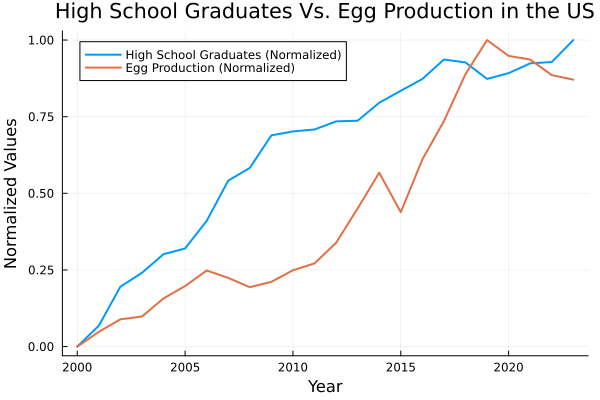

In [141]:
# Extract data
years = q1_data.Year
high_school = q1_data."High school graduates (Normalized)"
egg_production = q1_data."Total egg production (Normalized)"

# Plot
plot(years, high_school, label="High School Graduates (Normalized)", lw=2)
plot!(years, egg_production, label="Egg Production (Normalized)", lw=2)
title!("High School Graduates Vs. Egg Production in the US")
xlabel!("Year")
ylabel!("Normalized Values")

**Answer**:

- The plot shows a relationship between the normalized number of high school graduates and total egg production in the US from 2000 to 2023. Both variables are normalized to allow for comparison since they have different scales. The trends of the two variables appear to align over time, with both increasing in a somewhat similar pattern. (Reference 1 & 2)

- As seen in the plot, there is a visual similarity between the upward trends of both variables. While this might suggest a potential correlation, the two datasets represent unrelated phenomena, which one measures educational milestones, and the other measure agricultural productivity.

- I think the relationship between high school graduates and egg production is an example of a spurious correlation. The observed similarity in trends is likely coincidental and driven by external factors, such as general population growth or overall economic development, which independently affect both variables. There is no logical or causal mechanism to link the number of high school graduates to egg production directly. Thus, any statistical correlation between these variables is misleading and does not represent a true relationship.

### Problem 2

The underlying question we would like to address is: what is the
influence of drinking beer on the likelihood of being bitten by
mosquitoes? There is a mechanistic reason why this might occur:
mosquitoes are attracted by changes in body temperature and released
CO<sub>2</sub>, and it might be that drinking beer induces these
changes. We’ll analyze this question using (synthetic) data which
separates an experimental population into two groups, one which drank
beer and the other which drank only water.

First, we’ll load data for the number of bites reported by the
participants who drank beer. This is in a comma-delimited file,
`data/bites.csv` (which is grossly overkill for this assignment). Each
row contains two columns: the group (`beer` and `water`) the person
belonged to and the number of times that person was bitten.

In Julia, we can do this using
[`CSVFiles.jl`](https://github.com/queryverse/CSVFiles.jl), which will
read in the `.csv` file into a
[`DataFrame`](https://dataframes.juliadata.org/stable/), which is a
typical data structure for tabular data (and equivalent to a Pandas
`DataFrame` in Python or a `dataframe` in R).

In [3]:
data = DataFrame(load("data/bites.csv")) # load data into DataFrame

# print data variable (semi-colon suppresses echoed output in Julia, which in this case would duplicate the output)
@show data;

data = 43×2 DataFrame
 Row │ group   bites
     │ String  Int64
─────┼───────────────
   1 │ beer       27
   2 │ beer       20
   3 │ beer       21
   4 │ beer       26
   5 │ beer       27
   6 │ beer       31
   7 │ beer       24
   8 │ beer       21
   9 │ beer       20
  10 │ beer       19
  11 │ beer       23
  12 │ beer       24
  13 │ beer       28
  14 │ beer       19
  15 │ beer       24
  16 │ beer       29
  17 │ beer       18
  18 │ beer       20
  19 │ beer       17
  20 │ beer       31
  21 │ beer       20
  22 │ beer       25
  23 │ beer       28
  24 │ beer       21
  25 │ beer       27
  26 │ water      21
  27 │ water      22
  28 │ water      15
  29 │ water      12
  30 │ water      21
  31 │ water      16
  32 │ water      19
  33 │ water      15
  34 │ water      22
  35 │ water      24
  36 │ water      19
  37 │ water      23
  38 │ water      13
  39 │ water      22
  40 │ water      20
  41 │ water      24
  42 │ water      18
  43 │ water      20


How can we tell if there’s a meaningful difference between the two
groups? Naively, we might just look at the differences in group means.

> **Broadcasting**
>
> The subsetting operations in the below code use `.==`, which
> “broadcasts” the element-wise comparison operator == across every
> element. The decimal in front of `==` indicates that this should be
> used element-wise (every pair of elements compared for equality,
> returning a vector of `true` or `false` values); otherwise Julia would
> try to just check for vector equality (returning a single `true` or
> `false` value).
>
> Broadcasting is a very specific feature of Julia, so this syntax would
> look different in a different programming language.

In [4]:
# split data into vectors of bites for each group
beer = data[data.group .== "beer", :bites]
water = data[data.group .== "water", :bites]

observed_difference = mean(beer) - mean(water)
@show observed_difference;

observed_difference = 4.37777777777778


This tells us that, on average, the participants in the experiment who
drank beer were bitten approximately 4.4 more times than the
participants who drank water! Does that seem like a meaningful
difference, or could it be the result of random chance?

We will use a *simulation* approach to address this question, as
follows.

-   Suppose someone is skeptical of the idea that drinking beer could
    result in a higher attraction to mosquitoes, and therefore more
    bites. To this skeptic, the two datasets are really just different
    samples from the same underlying population of people getting bitten
    by mosquitoes, rather than two different populations with different
    propensities for being bitten. This is the skeptic’s *hypothesis*,
    versus our hypothesis that drinking beer changes body temperature
    and CO<sub>2</sub> release sufficiently to attract mosquitoes.
-   If the skeptic’s hypothesis is true, then we can “shuffle” all of
    the measurements between the two datasets and re-compute the
    differences in the means. After repeating this procedure a large
    number of times, we would obtain a distribution of the differences
    in means under the assumption that the skeptic’s hypothesis is true.
-   Comparing our experimentally-observed difference to this
    distribution, we can then evaluate the consistency of the skeptic’s
    hypothesis with the experimental results.

> **Why Do We Call This A Simulation-Based Approach?**
>
> This is a simulation-based approach because the “shuffling” is a
> non-parametric way of generating new samples from the underlying
> distribution (more on this later!).
>
> The alternative to this approach is to use a statistical test, such as
> a [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), which
> [may have other
> assumptions](https://en.wikipedia.org/wiki/Student%27s_t-test#Assumptions)
> which may not be appropriate for this setting, particularly given the
> seemingly small sample sizes.

**In this problem**:

-   Conduct the above procedure to generate 50,000 simulated datasets
    under the skeptic’s hypothesis.
-   Plot a histogram of the results and add a dashed vertical line to
    show the experimental difference (if you are using Julia, feel free
    to look at the [Making Plots with Julia
    tutorial](https://viveks.me/simulation-data-analysis/tutorials/julia-plots.html)
    on the class website).
-   Draw conclusions about the plausibility of the skeptic’s hypothesis
    that there is no difference between groups. Feel free to use any
    quantitative or qualitative assessments of your simulations and the
    observed difference.

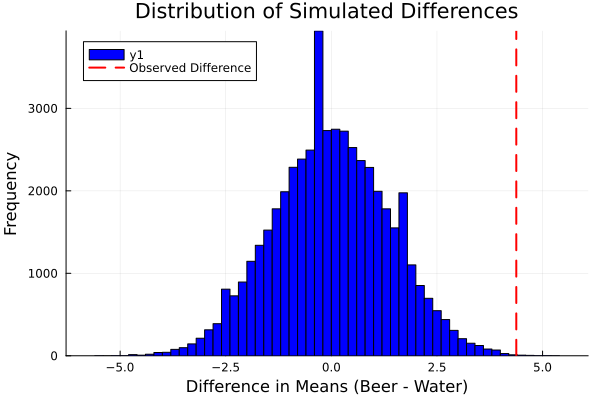

In [32]:
# Set seed
Random.seed!(38)

# Shuffle the group labels
n = 50000
simulated_differences = []

for i in 1:n
    shuffled_labels = shuffle(data.group)  
    data.shuffled_group = shuffled_labels

    # Calculate mean bites
    beer_mean = mean(data[data.shuffled_group .== "beer", :bites])
    water_mean = mean(data[data.shuffled_group .== "water", :bites])
    push!(simulated_differences, beer_mean - water_mean)
end

# Plot the results
histogram(simulated_differences, bins=50, color=:blue, edgecolor=:black,
    title="Distribution of Simulated Differences",
    xlabel="Difference in Means (Beer - Water)",
    ylabel="Frequency")
vline!([observed_difference], color=:red, linestyle=:dash, linewidth=2, label="Observed Difference")

In [23]:
extreme_count = sum(abs.(simulated_differences) .>= abs(observed_difference))
p_value = extreme_count / n

println("Observed Difference: ", observed_difference)
println("P-value: ", p_value)

Observed Difference: 4.37777777777778
P-value: 0.00098


**Answer**:

Based on the plot, the observed difference lies at the far right tail of the simulated null distribution. The calculated p-value of 0.00098 indicates that this observation is highly unlikely to occur under the null hypothesis, which assumes no relationship between alcohol consumption and mosquito bites. This provides strong evidence to reject the null hypothesis, suggesting that mosquito bites are indeed related to alcohol consumption.

### Problem 3

A scientific funding agency receives 200 proposals in response to a
call. The panel is asked to evaluate each proposal on two criteria:
scientific rigor and potential impact (or “newsworthiness”). After
standardizing each of these scores to independently follow a standard
normal distribution ($\text{Normal}(0, 1)$), the two standardized scores
are summed to get the total score for the proposal. Based on these total
scores, the top 10% of the proposals are selected for funding.

A researcher who is studying the relationship between rigor and impact
has used data on the funded proposals to claim high-impact proposals are
necessarily less rigorous, and indeed found a statistically significant
negative correlation between the rigor and impact scores for the funded
proposals. You are more skeptical and believe this effect is an artifact
from the selection process, which would make the claim a bit ironic.

**In this problem**:

-   Create a generative model for the grant-selection procedure under
    the null assumption of no correlation between rigor and impact. You
    can sample rigor and impact scores directly from
    $\text{Normal}(0, 1)$.
-   Using 1,000 simulations, compare the distribution of correlations
    between rigor and impact for the funded proposals to the general
    proposal population.
-   Explain why, when conditioning on selection for funding, there might
    be a negative correlation between rigor and impact even when none
    generally exists.

> **Selection-Distortion Effects**
>
> These **selection-distortion effects** are pretty common in
> observational data, going back to [work by Dawes in the 1970s on the
> lack of predictive ability of admission variables on student
> success](https://www.science.org/doi/abs/10.1126/science.187.4178.721)
> and including [studies claiming to identify a causal fingerprint of
> genes on
> outcomes](https://www.nature.com/articles/s41598-021-89020-x).
>
> This is, of course, just one example of how not thinking carefully
> about data-generating processes can fundamentally contaminate
> statistical analyses, emphasizing that **data do not have meaning
> absent a model for how they were generated**.

In [45]:
# Generative model function
function simulate_correlation(n_proposals, top_percentage)
    Random.seed!(38)
    rigor_scores = rand(Normal(0, 1), n_proposals)
    impact_scores = rand(Normal(0, 1), n_proposals)

    total_scores = rigor_scores .+ impact_scores

    # Create a DataFrame for storing proposals
    proposals = DataFrame(
        rigor = rigor_scores,
        impact = impact_scores,
        totalscore = total_scores
    )

    # Select the top 10%
    top_n = Int(n_proposals * top)
    funded_proposals = sort(proposals, :totalscore, rev = true)[1:top_n, :] # Reference 3

    # Compute correlations
    correlation_general = cor(proposals.rigor, proposals.impact)          
    correlation_funded = cor(funded_proposals.rigor, funded_proposals.impact)  

    return correlation_general, correlation_funded
end

simulate_correlation (generic function with 1 method)

In [53]:
# Run 1000 simulations

n_simulations = 1000
n_proposals = 200
top_percentage = 0.1

general_corrs = []
funded_corrs = []

for i in 1:n_simulations
    corr_general, corr_funded = simulate_correlation(n_proposals, top_percentage)
    push!(general_corrs, corr_general)
    push!(funded_corrs, corr_funded)
end

# Print summary statistics
println("Mean correlation (General Population): ", mean(general_corrs))
println("Mean correlation (Funded Proposals): ", mean(funded_corrs))

Mean correlation (General Population): 0.0795438739446425
Mean correlation (Funded Proposals): -0.6727722382462491


**Answer**:

The simulation shows a negative correlation among the selected funded proposals, whereas the general population shows little to no correlation. This negative correlation likely exists because, for a proposal's total score to rank in the top 10%, at least one of its components (rigor or impact) must be significantly above the average. As a result, some proposals achieve a high total score due to an exceptionally high impact score, even if their rigor score is relatively low.

### Problem 4

You are trying to detect how prevalent cheating was on an exam. You are
skeptical of the efficacy of just asking the students if they cheated.
You are also concerned about privacy — your goal is not to punish
individual students, but to see if there are systemic problems that need
to be addressed. Someone proposes the following interview procedure,
which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

We have a hypothesis that cheating was not prevalent, and the proportion
of cheaters was no more than 5% of the class; in other words, we expect
5 “true” cheaters out of a class of 100 students. Our TA is more jaded
and thinks that cheating was more rampant, and that 30% of the class
cheated. The proposed interview procedure is noisy: the interviewer does
not know if an admission means that the student cheated, or the result
of a heads. However, it gives us a data-generating process that we can
model and analyze for consistency with our hypothesis and that of the
TA.

**In this problem**:

-   Derive and code a simulation model for the above interview procedure
    given the “true” probability of cheating $p$.
-   Simulate your model (for a class of 100 students) 50,000 times under
    a null hypothesis of no cheating, your hypothesis of 5% cheating,
    the TA’s hypothesis of 30% cheating, and plot the resulting
    datasets.
-   If you received 31 “Yes, I cheated” responses while interviewing
    your class, what could you conclude?
-   How useful do you think the interview procedure is to identify
    systemic cheating? What changes to the design might you make?

In [149]:
# Simulation model

function interview(n_students,p_cheating)

    # The given "true" probability of cheating
    true_cheating = rand(Binomial(1, p_cheating), n_students)

    # Flip the coin
    first_flip = rand(Bool, n_students)  
    second_flip = rand(Bool, n_students) 

    # Determine Responses
    responses = zeros(Int, n_students)
    for i in 1:n_students
        if first_flip[i] == 1 # heads
            if true_cheating[i] == 1 # true cheater
                responses[i] = 1 # did cheat
            else
                responses[i] = 0 # did not cheat
            end
        else
            if second_flip[i] == 1 # head
                responses[i] = 1 # did cheat
            else
                responses[i] = 0 # did not cheat
            end
        end
    end
return responses
end


interview (generic function with 1 method)

Mean number of 'Yes' responses: 25.02722
Standard deviation: 4.321445657352573


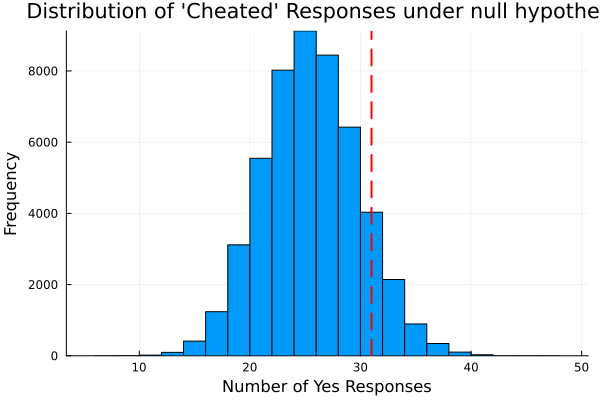

In [162]:
# Simulate over 50,000 times

function simulator(n_students, p_cheating, n_simulations)
    total_yes_responses = zeros(Int, n_simulations) 
    
    for sim in 1:n_simulations
        responses = interview(n_students, p_cheating)
        # Count the number of "cheated" responses
        total_yes_responses[sim] = sum(responses .== 1)
    end
    
    return total_yes_responses
end

# Set parameters
Random.seed!(37)
n_students = 100  
n_simulations = 50000
observed_31 = 31

# no cheating
p_cheating = 0

# Run the simulation
results = simulator(n_students, p_cheating, n_simulations)

# Analyze and plot the results
println("Mean number of 'Yes' responses: ", mean(results))
println("Standard deviation: ", std(results))
histogram(results, bins=30, title="Distribution of 'Cheated' Responses under null hypothesis", 
xlabel="Number of Yes Responses", ylabel="Frequency", legend=false)
vline!([observed_31], color=:red, linestyle=:dash, linewidth=2, label="Observed 31 'Yes' response")

Mean number of 'Yes' responses: 27.49938
Standard deviation: 4.485207013866712


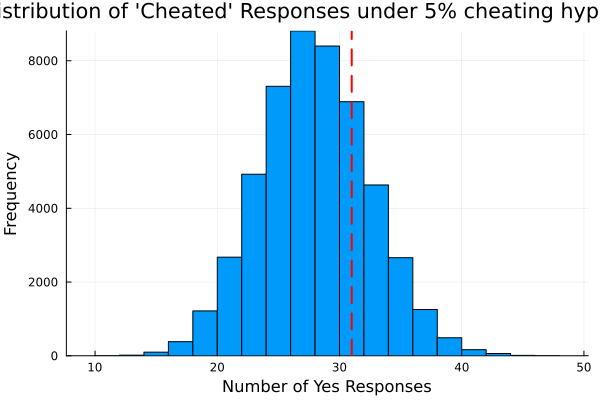

In [163]:
# 5% cheating
Random.seed!(38)
p_cheating = 0.05
n_students = 100  
n_simulations = 50000

# Run the simulation
results = simulator(n_students, p_cheating, n_simulations)

# Analyze and plot the results
println("Mean number of 'Yes' responses: ", mean(results))
println("Standard deviation: ", std(results))
histogram(results, bins=30, title="Distribution of 'Cheated' Responses under 5% cheating hypothesis", 
xlabel="Number of Yes Responses", ylabel="Frequency", legend=false)
vline!([observed_31], color=:red, linestyle=:dash, linewidth=2, label="Observed 31 'Yes' response")

Mean number of 'Yes' responses: 39.98584
Standard deviation: 4.888946464254912


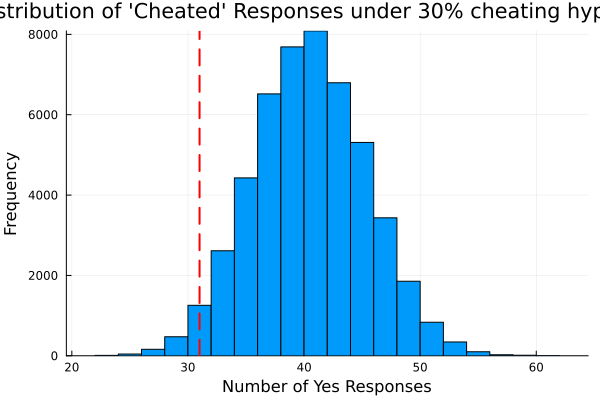

In [164]:
# 30% cheating
Random.seed!(39)
p_cheating = 0.3
n_students = 100  
n_simulations = 50000

# Run the simulation
results = simulator(n_students, p_cheating, n_simulations)

# Analyze and plot the results
println("Mean number of 'Yes' responses: ", mean(results))
println("Standard deviation: ", std(results))
histogram(results, bins=30, title="Distribution of 'Cheated' Responses under 30% cheating hypothesis", 
xlabel="Number of Yes Responses", ylabel="Frequency", legend=false)
vline!([observed_31], color=:red, linestyle=:dash, linewidth=2, label="Observed 31 'Yes' response")

**Answer**:

- If there are 31 'Yes' responses, it suggests that the cheating rate might be closer to 5%, as the mean value of approximately 27.5 for the 5% cheating hypothesis is the closest to 31 compering to the null hypothesis and the 30% hypothesis. However, this conclusion is not definitive, as the responses include randomness due to the coin flip process, and the observed result might still be influenced by chance.

- This method reduced fear of admission by preserves anonymity and encouraging honest responses; it also incorporates randomness, allowing statistical analysis to infer cheating prevalence without direct accusation. I would adjust the coin procedure by using a weithed coin depending on expected prevalence so that it could balance the noise and improve accuracy in estimating cheating rates. Based on simulations across different hypotheses (e.g., 0%, 5%, and 30% cheating rates), the observed mean number of "cheated" responses tends to be higher than expected. For instance, with a true cheating probability of 0%, the mean number of "Yes" responses is approximately 25 due to the coin-flipping mechanics. This suggests that the procedure introduces noise, which can make it harder to accurately estimate the true prevalence of cheating. Another change I would make is to increase the population size to reduce variability in results.

### Problem 5

**This problem is only required for students in BEE 5850**.

Adjusting for inflation, there has been an increase in tropical cyclone
damages on the U.S. Atlantic coast between 1900 and 2022 (see
<a href="#fig-tc" class="quarto-xref">Figure 1</a>).

<figure id="fig-tc">
<img src="attachment:figures/normalized-TC-damages.jpg" />
<figcaption>Figure 1: Change in tropical cyclone damages in U.S.
Atlantic coastal counties from 1900–2022, aggregated by pentad and
normalized to 2018 U.S. dollars. The red line shows an exponential trend
of 1.06%/yr growth in damages. Reproduced from <a
href="https://doi.org/10.1175/JAMC-D-24-0047.1">Willoughby, Hernandez,
&amp; Pinnock (2024)</a>.</figcaption>
</figure>

**In this problem**:

-   Describe two different mechanisms by which tropical cyclone damages
    in coastal counties might have increased over this period.
-   How might you propose to examine the relative strengths of these
    mechanisms? You don’t need to actually do this (this is indeed a
    somewhat thorny debate in the literature), but think about potential
    modeling and data approaches.

## References

Reference 1:
High school graduates, by sex and control of school: Selected years, 1869-70 through 2027-28

https://nces.ed.gov/programs/digest/d17/tables/dt17_219.10.asp

Reference 2:
Total egg production in the United States from 2000 to 2023

https://www.statista.com/statistics/196096/total-egg-production-in-the-us-since-2000/

Reference 3:
Sorting functions

https://docs.julialang.org/en/v1/base/sort/